In [1]:
# Import libraries
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn

In [2]:

# Path for IXI dataset
ixi_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\image slice-T2"

# Path for BraTS2020 
brats_train_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"
brats_val_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_ValidationData\MICCAI_BraTS2020_ValidationData"

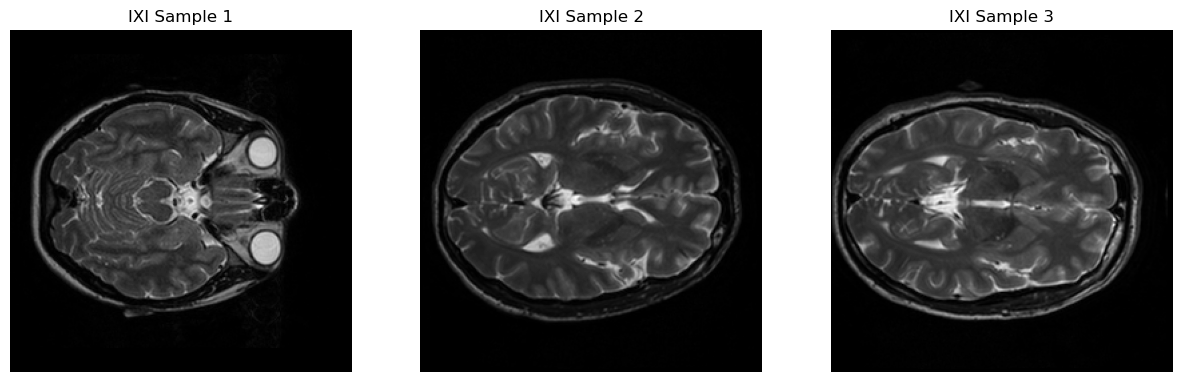

In [3]:
# IXI dataset
def load_ixi_sample(path, num_samples=3):
    folders = os.listdir(path)
    sample_images = []
    for folder in folders[:num_samples]:  
        folder_path = os.path.join(path, folder)
        image_files = os.listdir(folder_path)
        first_image = os.path.join(folder_path, image_files[0])  
        img = Image.open(first_image)
        sample_images.append(np.array(img))
    return sample_images
ixi_samples = load_ixi_sample(ixi_path)
# Plot the samples
plt.figure(figsize=(15, 5))
for i, sample in enumerate(ixi_samples):
    plt.subplot(1, len(ixi_samples), i + 1)
    plt.imshow(sample, cmap='gray')
    plt.title(f"IXI Sample {i + 1}")
    plt.axis('off')
plt.show()

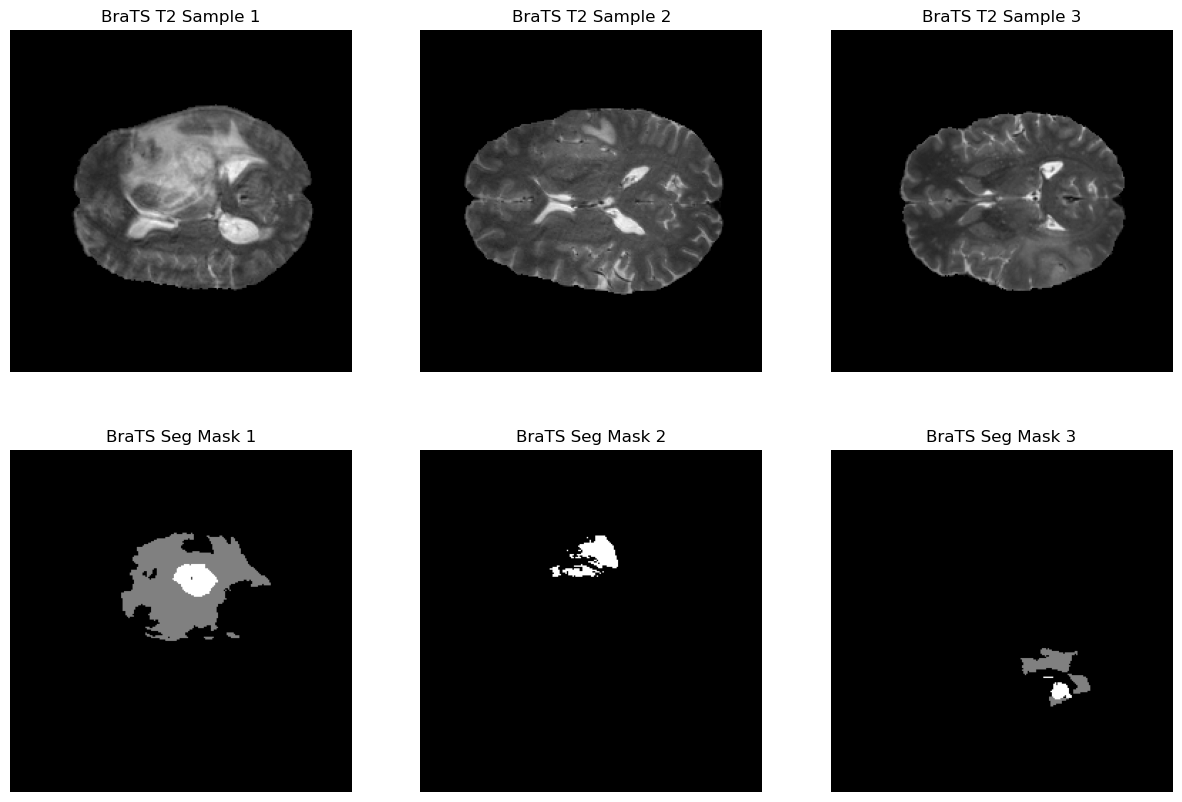

In [4]:
# BraTS2020
def load_brats_sample(path, num_samples=3):
    folders = os.listdir(path)
    images, masks = [], []
    for folder in folders[:num_samples]: 
        folder_path = os.path.join(path, folder)
        t2_image = nib.load(os.path.join(folder_path, f"{folder}_t2.nii")).get_fdata()
        seg_image = nib.load(os.path.join(folder_path, f"{folder}_seg.nii")).get_fdata()
        # Select a middle slice for display
        middle_slice = t2_image.shape[2] // 2
        images.append(t2_image[:, :, middle_slice])
        masks.append(seg_image[:, :, middle_slice])
    return images, masks

brats_images, brats_masks = load_brats_sample(brats_train_path)

# Plot the samples
plt.figure(figsize=(15, 10))
for i, (image, mask) in enumerate(zip(brats_images, brats_masks)):
    plt.subplot(2, len(brats_images), i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"BraTS T2 Sample {i + 1}")
    plt.axis('off')
    
    plt.subplot(2, len(brats_images), i + 1 + len(brats_images))
    plt.imshow(mask, cmap='gray')
    plt.title(f"BraTS Seg Mask {i + 1}")
    plt.axis('off')
plt.show()


In [5]:
#  IXI Dataset Loader
import os
import torch
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import torch.nn.functional as F

class TriVAEDataset(Dataset):

    def __init__(self, root_dir, transform=None, coarse_noise_std=0.2, coarse_noise_resolution=16):
        
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []

        folders = os.listdir(root_dir)
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            if not os.path.isdir(folder_path):
                continue
            for file in os.listdir(folder_path):
                if file.endswith(".png"):
                    self.samples.append(os.path.join(folder_path, file))

        self.coarse_noise_std = coarse_noise_std
        self.coarse_noise_resolution = coarse_noise_resolution

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
      
        img_path = self.samples[idx]
        image_pil = Image.open(img_path).convert("L")  

        if self.transform:
            image = self.transform(image_pil)  # [1, 256, 256]
        else:
            
            image = torch.from_numpy(np.array(image_pil)).float().unsqueeze(0) / 255.0

        # Anchor and Positive 
        anchor = image.clone()
        positive = image.clone()

        # Create Negative by adding coarse noise
        negative = self.add_coarse_noise(image)

        return anchor, positive, negative

    def add_coarse_noise(self, img):
       
        # 1) Generate low-res noise (e.g. 16x16) from Gaussian(0, self.coarse_noise_std)
        low_res_noise = torch.randn(
            (1, self.coarse_noise_resolution, self.coarse_noise_resolution)
        ) * self.coarse_noise_std

        # 2) Upsample (bilinear) to [1, 256, 256]
        upsampled_noise = F.interpolate(
            low_res_noise.unsqueeze(0),
            size=(256, 256),
            mode='bilinear',
            align_corners=False
        ).squeeze(0)

        # 3) Add noise to the original image
        negative = img + upsampled_noise
       
        negative = torch.clamp(negative, 0.0, 1.0)
        return negative

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
])

# Instantiate the dataset and dataloader
ixi_root = r"C:\Users\user\Desktop\MASTER\NN\HW6\image slice-T2"
tri_vae_dataset = TriVAEDataset(root_dir=ixi_root, transform=transform)
ixi_loader = DataLoader(tri_vae_dataset, batch_size=4, shuffle=True)


In [6]:
# Gated Cross Skip (GCS)

import torch
import torch.nn as nn
import torch.nn.functional as F

class GatedCrossSkip(nn.Module):
    
    def __init__(self, in_channels_enc, in_channels_dec, reduction=4):
        super(GatedCrossSkip, self).__init__()

        self.reduced_enc = in_channels_enc // reduction
        self.reduced_dec = in_channels_dec // reduction

        self.conv_enc = nn.Conv2d(in_channels_enc, self.reduced_enc, kernel_size=1)
        self.conv_dec = nn.Conv2d(in_channels_dec, self.reduced_dec, kernel_size=1)

        # Learnable parameters alpha, beta
        self.alpha = nn.Parameter(torch.tensor(1.0))
        self.beta  = nn.Parameter(torch.tensor(0.0))

        self.conv_out = nn.Conv2d(self.reduced_enc, in_channels_dec, kernel_size=1)

        self.tanh = nn.Tanh()

    def forward(self, E, D):
        
        # Project each to lower dimension
        E_reduced = self.conv_enc(E)  
        D_reduced = self.conv_dec(D)  
        # Cross-attention: att_map = tanh(E_reduced) * D_reduced
        att_map = self.tanh(E_reduced) * D_reduced
        combined = self.alpha * att_map + self.beta * E_reduced
        out = self.conv_out(combined)  
        return out


In [7]:
# VAE with skip outputs and GCS

class Encoder(nn.Module):
    
    def __init__(self, latent_dim=128):
        super(Encoder, self).__init__()

        # Convolution blocks
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)  
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1) 
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)

        self.relu  = nn.ReLU(inplace=True)

        self.fc_mu     = nn.Linear(128 * 32 * 32, latent_dim)
        self.fc_logvar = nn.Linear(128 * 32 * 32, latent_dim)

    def forward(self, x):
        e1 = self.relu(self.conv1(x))   
        e2 = self.relu(self.conv2(e1))  
        e3 = self.relu(self.conv3(e2))  

        b  = e3.view(e3.size(0), -1)    
        mu = self.fc_mu(b)
        logvar = self.fc_logvar(b)

        return e1, e2, e3, mu, logvar


class Decoder(nn.Module):
    
    def __init__(self, latent_dim=128):
        super(Decoder, self).__init__()

        self.fc = nn.Linear(latent_dim, 128 * 32 * 32)

        # Transpose conv to go back to 256x256
        self.tconv1 = nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1)
        self.tconv2 = nn.ConvTranspose2d(64, 32,  kernel_size=3, stride=2, padding=1, output_padding=1)
        self.tconv3 = nn.ConvTranspose2d(32, 1,   kernel_size=3, stride=2, padding=1, output_padding=1)

        self.relu = nn.ReLU(inplace=True)
        self.sigmoid = nn.Sigmoid()

        # For GCS: We will do one skip connection from e2 -> tconv1
        self.gcs_block = GatedCrossSkip(in_channels_enc=64, in_channels_dec=64, reduction=4)

        # 1x1 conv to produce coarse scale from e3 directly 
        self.coarse_head = nn.Conv2d(128, 1, kernel_size=1) 
        # Then we apply a Sigmoid to get the final coarse
    def forward(self, z, e1, e2, e3):
        # Re-expand latent
        x = self.fc(z)    
        x = x.view(-1, 128, 32, 32) 

        coarse_out = self.sigmoid(self.coarse_head(x))

        x = self.relu(self.tconv1(x))  

        # GCS from e2 -> x
        
        gcs_out = self.gcs_block(e2, x)  

        x = self.relu(self.tconv2(gcs_out)) 

        # Up conv to 256x256
        x = self.tconv3(x)              
        full_out = self.sigmoid(x)      

        return coarse_out, full_out


In [8]:
# TriVAE model 

class TriVAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(TriVAE, self).__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(latent_dim=self.latent_dim)
        self.decoder = Decoder(latent_dim=self.latent_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # 1) Encode
        e1, e2, e3, mu, logvar = self.encoder(x)
        # For triplet embedding
        embedding = mu.clone()

        # 2) Sample z
        z = self.reparameterize(mu, logvar)

        # 3) Decode
        coarse_out, full_out = self.decoder(z, e1, e2, e3)

        return coarse_out, full_out, mu, logvar, embedding


In [9]:
# Loss Functions

import torch
import torch.nn.functional as F
import torchmetrics.functional as FM

def loss_recon_L1(pred, target):
    return torch.mean(torch.abs(pred - target))

def kld_loss(mu, logvar):
    # Standard VAE KL Divergence
    return 0.5 * torch.mean(mu**2 + torch.exp(logvar) - logvar - 1)

def triplet_loss(anchor_emb, positive_emb, negative_emb, margin=1.0):
    # squared L2 distances
    d_ap = torch.sum((anchor_emb - positive_emb)**2, dim=1)
    d_an = torch.sum((anchor_emb - negative_emb)**2, dim=1)
    losses = torch.relu(d_ap - d_an + margin)
    return torch.mean(losses)

def ssim_loss(pred, target):
    
    ssim_val = FM.structural_similarity_index_measure(pred, target, data_range=1.0)
    return 1.0 - ssim_val


In [11]:
# Training Loop

import torch
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt

def train_tri_vae_model(model, loader, epochs=20):
    """
    Training function for the TriVAE model with a manual learning rate schedule:
      - 1e-3 for epochs 1..5
      - 1e-4 for epochs 6..10
      - 1e-5 for epochs 11..15
      - 1e-6 for epochs 16..20
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Using device:", device)

    model.to(device)
    # Initial LR 
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    epoch_losses = []

    for epoch in range(1, epochs + 1):
        # Manually adjust LR 
        if 1 <= epoch <= 5:
            current_lr = 1e-3
        elif 6 <= epoch <= 10:
            current_lr = 1e-4
        elif 11 <= epoch <= 15:
            current_lr = 1e-5
        else:
            current_lr = 1e-6

        for param_group in optimizer.param_groups:
            param_group['lr'] = current_lr

        model.train()
        total_loss_val = 0.0

        pbar = tqdm(loader, desc=f"Epoch {epoch}/{epochs} (lr={current_lr})")

        for (anchor, positive, negative) in pbar:
            anchor   = anchor.to(device)
            positive = positive.to(device)
            negative = negative.to(device)

            optimizer.zero_grad()

            # Forward passes
            anchor_coarse, anchor_full, mu_a, logvar_a, emb_a = model(anchor)
            pos_coarse, pos_full, mu_p, logvar_p, emb_p = model(positive)
            neg_coarse, neg_full, mu_n, logvar_n, emb_n = model(negative)

            # 1) L1 Reconstruction Loss
            anchor_coarse_gt = F.interpolate(anchor, size=(32,32), mode='bilinear', align_corners=False)
            pos_coarse_gt    = F.interpolate(positive, size=(32,32), mode='bilinear', align_corners=False)
            neg_coarse_gt    = F.interpolate(negative, size=(32,32), mode='bilinear', align_corners=False)

            L1_anchor_coarse = loss_recon_L1(anchor_coarse, anchor_coarse_gt)
            L1_pos_coarse    = loss_recon_L1(pos_coarse, pos_coarse_gt)
            L1_neg_coarse    = loss_recon_L1(neg_coarse, neg_coarse_gt)
            L1_neg_full      = loss_recon_L1(neg_full, negative)
            L1_total = L1_anchor_coarse + L1_pos_coarse + L1_neg_coarse + L1_neg_full

            # 2) KLD (Anchor + Positive only)
            KLD_anchor = kld_loss(mu_a, logvar_a)
            KLD_pos    = kld_loss(mu_p, logvar_p)
            KLD_total  = KLD_anchor + KLD_pos

            # 3) Triplet Loss
            L_triplet  = triplet_loss(emb_a, emb_p, emb_n, margin=1.0)

            # 4) SSIM on negative full
            SSIM_neg   = ssim_loss(neg_full, negative)

            # Final loss
            loss = L1_total + KLD_total + L_triplet + SSIM_neg

            loss.backward()
            optimizer.step()

            total_loss_val += loss.item()
            pbar.set_postfix({"loss": f"{loss.item():.4f}"})

        avg_loss = total_loss_val / len(loader)
        epoch_losses.append(avg_loss)
        print(f"[Epoch {epoch}/{epochs}] Average Loss: {avg_loss:.4f}")

    plt.figure()
    plt.plot(range(1, epochs + 1), epoch_losses, marker='o')
    plt.title('Training Loss Over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()


Using device: cuda


Epoch 1/20 (lr=0.001): 100%|██████████| 7213/7213 [11:16<00:00, 10.67it/s, loss=0.1902]


[Epoch 1/20] Average Loss: 0.2393


Epoch 2/20 (lr=0.001): 100%|██████████| 7213/7213 [07:49<00:00, 15.37it/s, loss=0.1766]


[Epoch 2/20] Average Loss: 0.1918


...

[Epoch 18/20] Average Loss: 0.1669


Epoch 19/20 (lr=1e-06): 100%|██████████| 7213/7213 [07:39<00:00, 15.71it/s, loss=0.1822]


[Epoch 19/20] Average Loss: 0.1668


Epoch 20/20 (lr=1e-06): 100%|██████████| 7213/7213 [07:38<00:00, 15.73it/s, loss=0.1639]


[Epoch 20/20] Average Loss: 0.1668


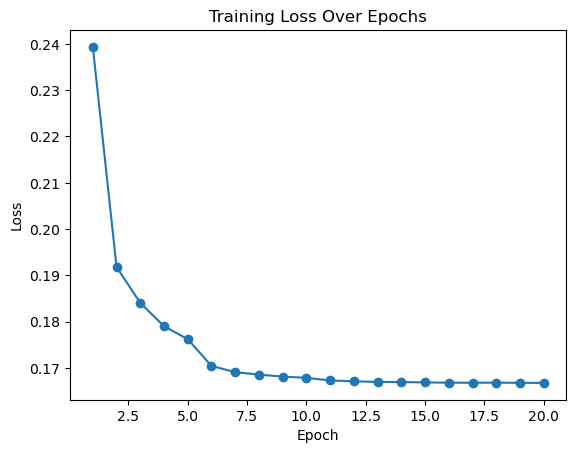

In [14]:
model = TriVAE(latent_dim=128)
train_tri_vae_model(model, ixi_loader, epochs=20)

# Testing and Evaluating the model and calculating dice score average for 100 patients

In [24]:
# Dice function

import os
import nibabel as nib
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Dice function for 2D masks:
def dice_coefficient_2d(pred_mask, true_mask):
    
    intersection = np.sum(pred_mask * true_mask)
    sum_of_masks = np.sum(pred_mask) + np.sum(true_mask)
    if sum_of_masks == 0:
        return 1.0  # If both masks are empty, Dice = 1
    dice = 2.0 * intersection / sum_of_masks
    return dice


In [25]:
# load T2 & seg 

def load_brats_t2_and_seg(patient_folder):
    
    t2_path = os.path.join(patient_folder, os.path.basename(patient_folder) + "_t2.nii")
    seg_path = os.path.join(patient_folder, os.path.basename(patient_folder) + "_seg.nii")

    t2_nib = nib.load(t2_path)
    seg_nib = nib.load(seg_path)

    t2_vol = t2_nib.get_fdata()  
    seg_vol = seg_nib.get_fdata()
    t2_vol = t2_vol.astype(np.float32)
    seg_vol = seg_vol.astype(np.float32)

    return t2_vol, seg_vol


<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
C:\Users\user\AppData\Local\Temp\ipykernel_13716\3754961640.py:4: SyntaxWarning: invalid escape sequence '\.'
  """


In [27]:
# Test function

from torchvision import transforms
def test_tri_vae_on_brats(model, brats_root, num_patients=100, 
                          error_threshold=0.1, device='cuda'):
    model.eval().to(device)

    all_folders = sorted([
        os.path.join(brats_root, f) for f in os.listdir(brats_root)
        if os.path.isdir(os.path.join(brats_root, f))
    ])
    selected_folders = all_folders[:num_patients]

    dice_scores = []
    sample_visuals = []

    test_transform = transforms.Compose([
        transforms.ToPILImage(),     
        transforms.Resize((256,256)),
        transforms.ToTensor()
    ])

    with torch.no_grad():
        for patient_idx, folder in enumerate(selected_folders):
            t2_vol, seg_vol = load_brats_t2_and_seg(folder)
            D = t2_vol.shape[2]

            for slice_idx in range(D):
                t2_slice = t2_vol[:,:,slice_idx]
                seg_slice = seg_vol[:,:,slice_idx]

                slice_min, slice_max = t2_slice.min(), t2_slice.max()
                if slice_max > slice_min:
                    norm_slice = (t2_slice - slice_min) / (slice_max - slice_min)
                else:
                    norm_slice = t2_slice  

                norm_slice = norm_slice.astype(np.float32)

                norm_slice_uint8 = (norm_slice * 255).astype(np.uint8)  
                slice_tensor = test_transform(norm_slice_uint8)         
                slice_tensor = slice_tensor.unsqueeze(0).to(device)
                
                coarse_out, full_out, mu, logvar, emb = model(slice_tensor)

                # reconstruction error, threshold, dice,......
                recon = full_out[0,0].cpu().numpy()   
                original = slice_tensor[0,0].cpu().numpy()  
                error_map = np.abs(original - recon)

                pred_mask = (error_map > error_threshold).astype(np.uint8)

                seg_slice_resized = F.interpolate(
                    torch.from_numpy(seg_slice).unsqueeze(0).unsqueeze(0),
                    size=(256,256),
                    mode='nearest'
                )[0,0].numpy()

                gt_mask = (seg_slice_resized > 0).astype(np.uint8)
                dice_2d = dice_coefficient_2d(pred_mask, gt_mask)
                dice_scores.append(dice_2d)

                if patient_idx < 2 and slice_idx < 5:
                    sample_visuals.append({
                        'input_slice': original,
                        'error_map': error_map,
                        'pred_mask': pred_mask,
                        'gt_mask': gt_mask,
                        'dice': dice_2d
                    })

    return dice_scores, sample_visuals



In [28]:
# Testing on 100 patients from BraTS train

brats_path = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"

dice_scores, sample_visuals = test_tri_vae_on_brats(
    model, 
    brats_root=brats_path, 
    num_patients=100,   
    error_threshold=0.1, 
    device='cuda'        
)
print(f"Tested on {len(dice_scores)} slices across up to 100 patients.")
avg_dice = np.mean(dice_scores)
print(f"Average Dice across all slices: {avg_dice:.4f}")

Tested on 15500 slices across up to 100 patients.
Average Dice across all slices: 0.4764


In [59]:
# Test on ONE random slice, show Dice

def test_tri_vae_on_one_random_slice(model, brats_root, error_threshold=0.1, device='cuda'):

    model.eval().to(device)

    # Gather patient folders
    all_folders = sorted([
        os.path.join(brats_root, f) for f in os.listdir(brats_root)
        if os.path.isdir(os.path.join(brats_root, f))
    ])
    if not all_folders:
        print("No patient folders found in:", brats_root)
        return

    # 1) Random folder
    random_folder = random.choice(all_folders)
    
    # 2) Load T2 + seg volumes
    t2_vol, seg_vol = load_brats_t2_and_seg(random_folder)  # [H,W,D]
    H, W, D = t2_vol.shape
    
    # 3) Random slice
    slice_idx = random.randint(0, D-1)
    

    print("Randomly chosen folder:", random_folder)
    print("Randomly chosen slice:", slice_idx)

    # Extract slice
    t2_slice = t2_vol[:,:,slice_idx]  
    seg_slice = seg_vol[:,:,slice_idx]

    # Min-max normalize
    s_min, s_max = t2_slice.min(), t2_slice.max()
    if s_max > s_min:
        norm_slice = (t2_slice - s_min) / (s_max - s_min)
    else:
        norm_slice = t2_slice
    
    norm_slice = norm_slice.astype(np.float32)

    norm_slice_uint8 = (norm_slice * 255).astype(np.uint8)

    test_transform = transforms.Compose([
        transforms.ToPILImage(),     
        transforms.Resize((256, 256)),
        transforms.ToTensor()
    ])

    slice_tensor = test_transform(norm_slice_uint8)  

    slice_tensor = slice_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        coarse_out, full_out, mu, logvar, emb = model(slice_tensor)

    # Reconstructed slice
    recon = full_out[0,0].cpu().numpy()   
    original = slice_tensor[0,0].cpu().numpy()  
    error_map = np.abs(original - recon)

    # Threshold 
    pred_mask = (error_map > error_threshold).astype(np.uint8)

    # Resize GT seg slice to 256x256 
    seg_slice_resized = F.interpolate(
        torch.from_numpy(seg_slice).unsqueeze(0).unsqueeze(0),
        size=(256,256),
        mode='nearest'
    )[0,0].numpy()
    gt_mask_256 = (seg_slice_resized > 0).astype(np.uint8)

    # Compute Dice
    dice_val = dice_coefficient_2d(pred_mask, gt_mask_256)
    print(f"Dice for slice {slice_idx}: {dice_val:.3f}")

    fig, axs = plt.subplots(1, 5, figsize=(16,4))

    axs[0].imshow(original, cmap='gray')
    axs[0].set_title("Input Slice")
    axs[0].axis('off')

    axs[1].imshow(recon, cmap='gray')
    axs[1].set_title("Reconstruction")
    axs[1].axis('off')

    im2 = axs[2].imshow(error_map, cmap='hot')
    axs[2].set_title("Error Map")
    axs[2].axis('off')
    fig.colorbar(im2, ax=axs[2])

    axs[3].imshow(pred_mask, cmap='gray')
    axs[3].set_title(f"Pred. Mask (thr={error_threshold})")
    axs[3].axis('off')

    axs[4].imshow(gt_mask_256, cmap='gray')
    axs[4].set_title(f"GT Mask\nDice={dice_val:.3f}")
    axs[4].axis('off')

    plt.tight_layout()
    plt.show()


Randomly chosen folder: C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData\BraTS20_Training_285
Randomly chosen slice: 112
Dice for slice 112: 0.925


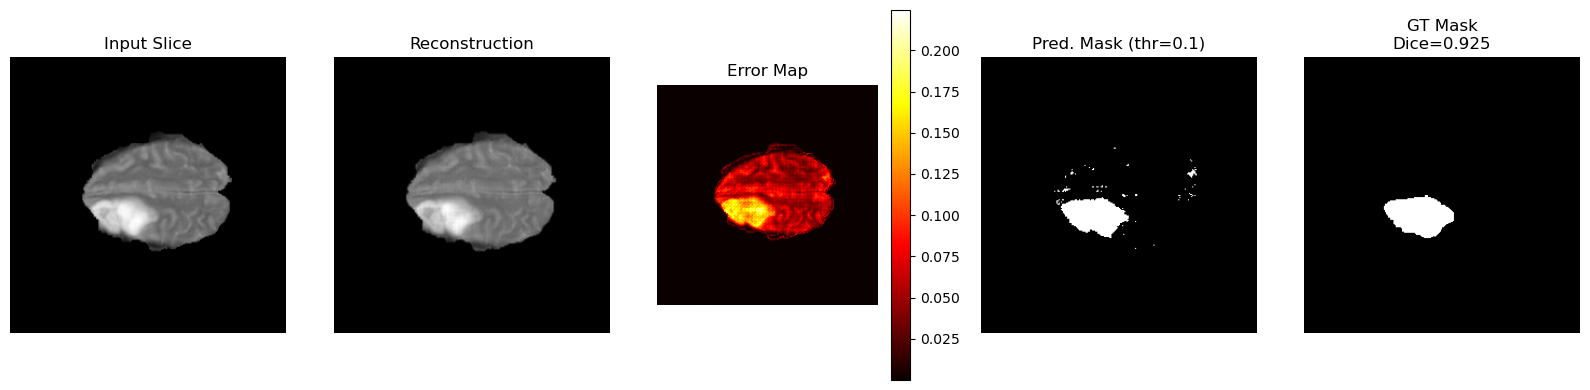

In [64]:
brats_root = r"C:\Users\user\Desktop\MASTER\NN\HW6\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData"
test_tri_vae_on_one_random_slice(
    model, 
    brats_root=brats_root, 
    error_threshold=0.1, 
    device='cuda'
)